In [1]:
# ==========================================
# Mutual Fund Analytics - EDA
# Day 3
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# Project paths
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed"
CHART_PATH = PROJECT_ROOT / "charts"

print("Setup Complete")

Setup Complete


In [2]:
fund_master = pd.read_csv(DATA_PATH/"01_fund_master_clean.csv")
nav_history = pd.read_csv(DATA_PATH/"02_nav_history_clean.csv")
aum = pd.read_csv(DATA_PATH/"03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(DATA_PATH/"04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(DATA_PATH/"05_category_inflows_clean.csv")
folios = pd.read_csv(DATA_PATH/"06_industry_folio_count_clean.csv")
performance = pd.read_csv(DATA_PATH/"07_scheme_performance_clean.csv")
transactions = pd.read_csv(DATA_PATH/"08_investor_transactions_clean.csv")
holdings = pd.read_csv(DATA_PATH/"09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(DATA_PATH/"10_benchmark_indices_clean.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folios["month"] = pd.to_datetime(folios["month"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Date conversion completed")

Date conversion completed


In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:20} {df.shape}")

Fund Master          (40, 15)
NAV History          (46000, 3)
AUM                  (90, 5)
SIP                  (48, 6)
Category             (144, 3)
Folios               (21, 6)
Performance          (40, 19)
Transactions         (32778, 13)
Holdings             (322, 8)
Benchmark            (8050, 3)


# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Mutual Fund Analytics dataset.

### Objectives

- Analyze NAV trends
- Study AUM growth
- Explore SIP inflows
- Understand investor demographics
- Analyze geographical investment distribution
- Examine portfolio allocation
- Generate business insights through visualization

# 1. NAV Trend Analysis

This visualization shows the daily Net Asset Value (NAV) movement for all mutual fund schemes from 2022 to 2026.

Highlighted regions:
- Green → 2023 Bull Run
- Red → 2024 Market Correction

In [9]:
# ======================================================
# NAV Trend Analysis
# ======================================================

import plotly.express as px
from pathlib import Path

# Ensure date column is datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Merge scheme names
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Create interactive line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.15,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="lightcoral",
    opacity=0.15,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Layout improvements
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    width=1300,
    legend_title="Scheme Name",
    title_x=0.5
)

fig.show()

In [6]:
(Path("../charts/nav")).mkdir(parents=True, exist_ok=True)

# Export PNG
fig.write_image(
    "../charts/nav/nav_trend_all_schemes.png",
    width=1600,
    height=900,
    scale=2
)

print("Chart exported successfully.")

Chart exported successfully.


### Insight 1

Most mutual fund schemes exhibited a steady increase in NAV between 2022 and 2026. Growth accelerated during the highlighted 2023 bull market, while the first half of 2024 showed comparatively slower appreciation and higher short-term fluctuations before recovering.

**Chart Reference:** Figure 1 – Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)

# 2. AUM Growth Analysis

This section analyzes the Assets Under Management (AUM) growth of different fund houses from 2022 to 2025.

The chart compares yearly AUM across fund houses and highlights the market leadership of SBI Mutual Fund.

In [10]:
# ======================================================
# AUM Growth Analysis
# ======================================================

# Extract Year
aum["year"] = aum["date"].dt.year

# Keep only required years
aum_plot = aum[aum["year"].between(2022, 2025)]

# Aggregate yearly AUM
aum_yearly = (
    aum_plot
    .groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .mean()
)

aum_yearly.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


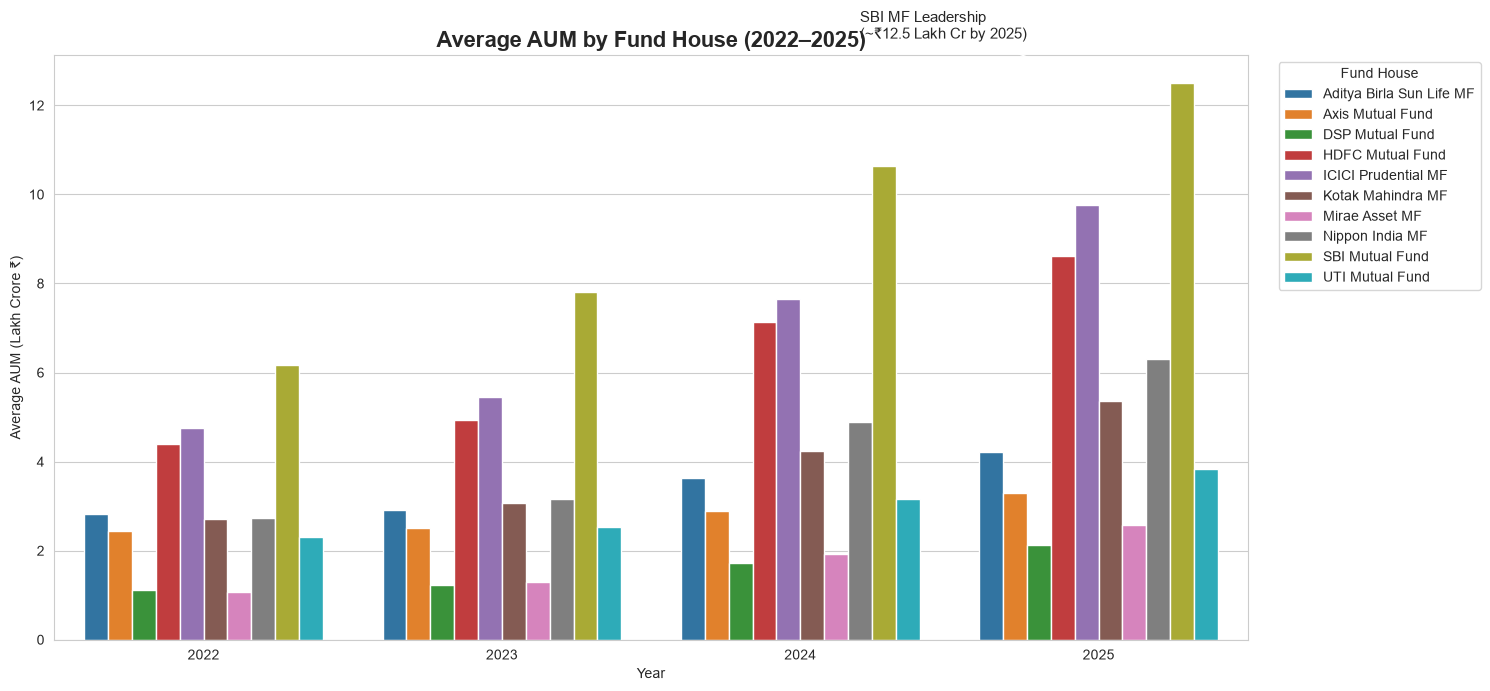

In [11]:
plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Average AUM by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Highlight SBI dominance
plt.annotate(
    "SBI MF Leadership\n(~₹12.5 Lakh Cr by 2025)",
    xy=(3,12.5),
    xytext=(2.2,13.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.tight_layout()

plt.show()

In [12]:
(Path("../charts/aum")).mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Average AUM by Fund House (2022–2025)")
plt.tight_layout()

plt.savefig(
    "../charts/aum/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("AUM chart exported successfully.")

AUM chart exported successfully.


### Insight 2

Assets Under Management increased steadily across major fund houses between 2022 and 2025. SBI Mutual Fund consistently maintained the highest AUM among the fund houses represented in the dataset, indicating its strong market position.

**Chart Reference:** Figure 2 – AUM Growth by Fund House

# 3. SIP Inflow Trend Analysis

This visualization shows the monthly SIP inflow trend from January 2022 to December 2025.

The chart highlights the highest recorded monthly SIP inflow.

In [15]:
# ======================================================
# SIP Inflow Trend
# ======================================================

import plotly.express as px

# Ensure datetime
sip["month"] = pd.to_datetime(sip["month"])

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

# Highlight maximum point
fig.add_scatter(
    x=[max_row["month"].strftime("%Y-%m-%d")],
    y=[max_row["sip_inflow_crore"]],
    mode="markers",
    marker=dict(size=12, color="red"),
    showlegend=False
)

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-60
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=1200,
    title_x=0.5
)

fig.show()

In [16]:
(Path("../charts/sip")).mkdir(parents=True, exist_ok=True)

fig.write_image(
    "../charts/sip/sip_inflow_trend.png",
    width=1600,
    height=900,
    scale=2
)

print("SIP trend chart exported successfully.")

SIP trend chart exported successfully.


### Insight 3

Monthly SIP inflows show a consistent upward trend over the study period, reflecting increasing retail investor participation. The highest monthly SIP inflow is clearly visible at the peak of the series, indicating sustained growth in systematic investments.

**Chart Reference:** Figure 3 – Monthly SIP Inflow Trend

# 4. Category-wise Net Inflow Heatmap

This heatmap compares monthly net inflows across mutual fund categories.

Darker shades indicate higher net inflows.

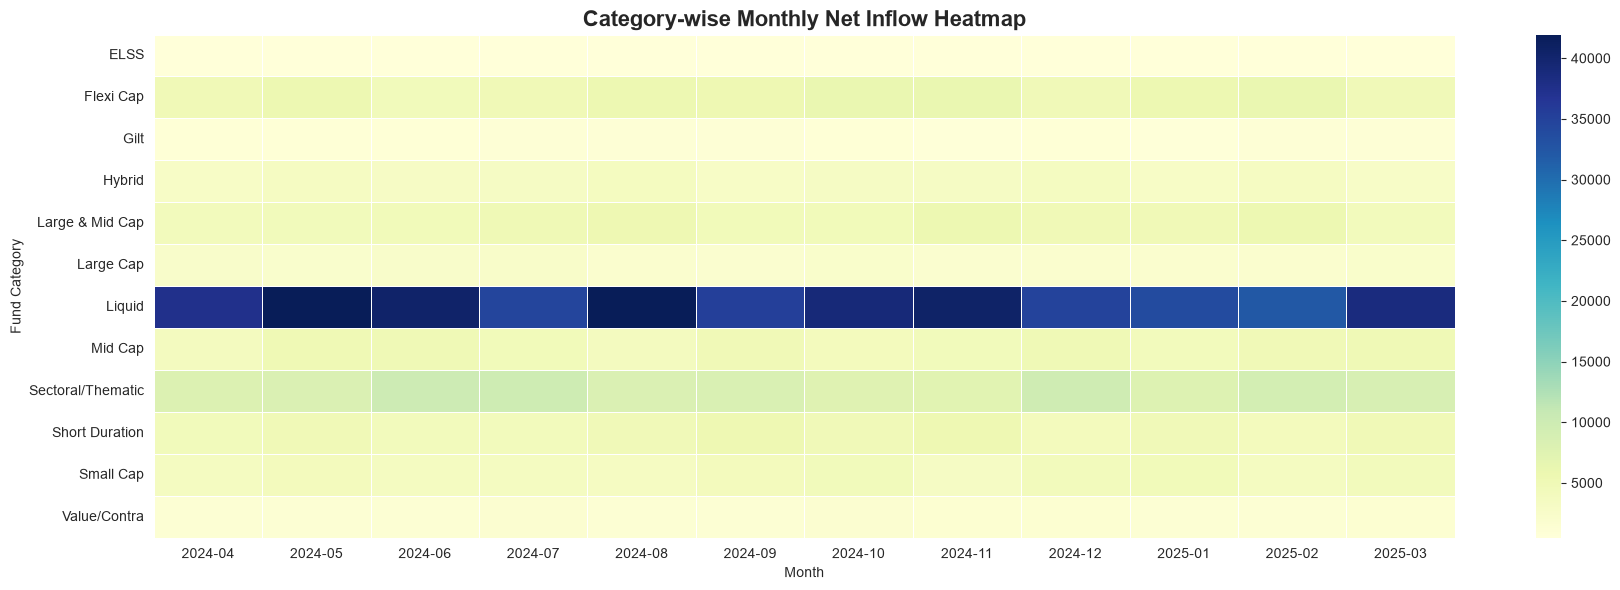

In [17]:
# ======================================================
# Category Inflow Heatmap
# ======================================================

category["month_str"] = category["month"].dt.strftime("%Y-%m")

heatmap_df = category.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

In [18]:
(Path("../charts/category")).mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../charts/category/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Category heatmap exported.")

Category heatmap exported.


### Insight 4

Net inflows varied across fund categories over time. Certain categories consistently attracted stronger investor interest, while others experienced comparatively lower inflows during different reporting months.

**Chart Reference:** Figure 4 – Category Inflow Heatmap

# 5. Investor Demographics

This section analyzes the demographic profile of investors based on age group, gender, and investment amount.

The objective is to understand participation patterns across different investor segments.

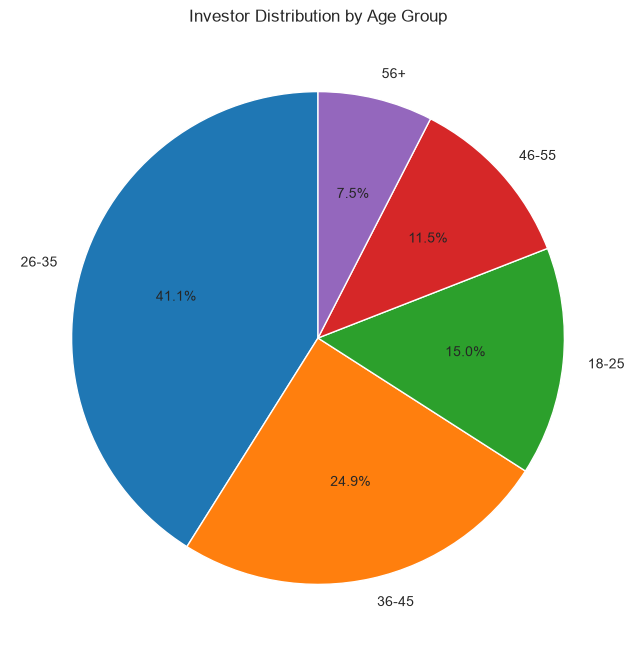

In [20]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "../charts/demographics/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5

The investor base is distributed across multiple age groups, with one segment contributing the largest share of investors. This indicates the primary demographic participating in mutual fund investments.

**Chart Reference:** Figure 5 – Age Group Distribution

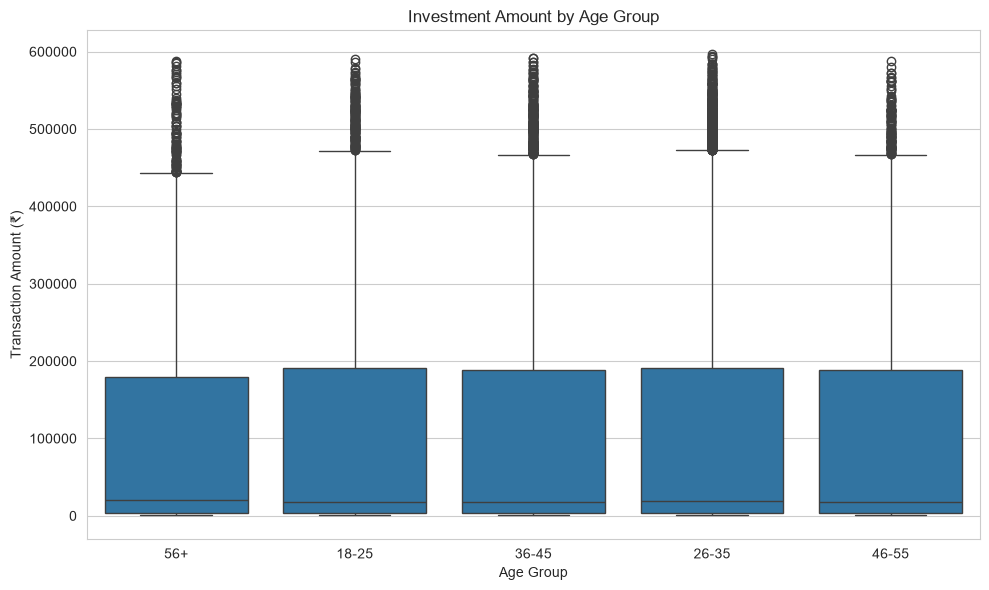

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../charts/demographics/age_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

Investment amounts vary across age groups, with some segments exhibiting a wider spread in transaction values. This suggests differences in investment capacity and behavior among investors.

**Chart Reference:** Figure 6 – Investment Amount by Age Group

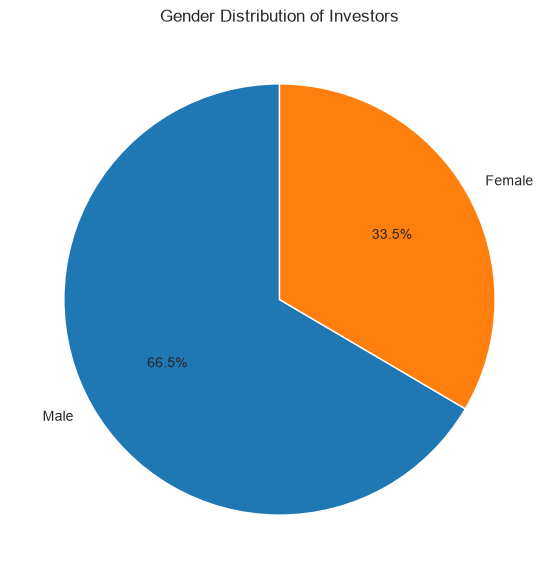

In [22]:
plt.figure(figsize=(7,7))

gender = transactions["gender"].value_counts()

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../charts/demographics/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7

The gender distribution highlights participation across investor groups and provides an overview of the demographic balance within the dataset.

**Chart Reference:** Figure 7 – Gender Distribution

# 6. Geographic Distribution

This section examines the geographical distribution of investments based on state and city tier classification.

The analysis helps identify regions with higher mutual fund participation.

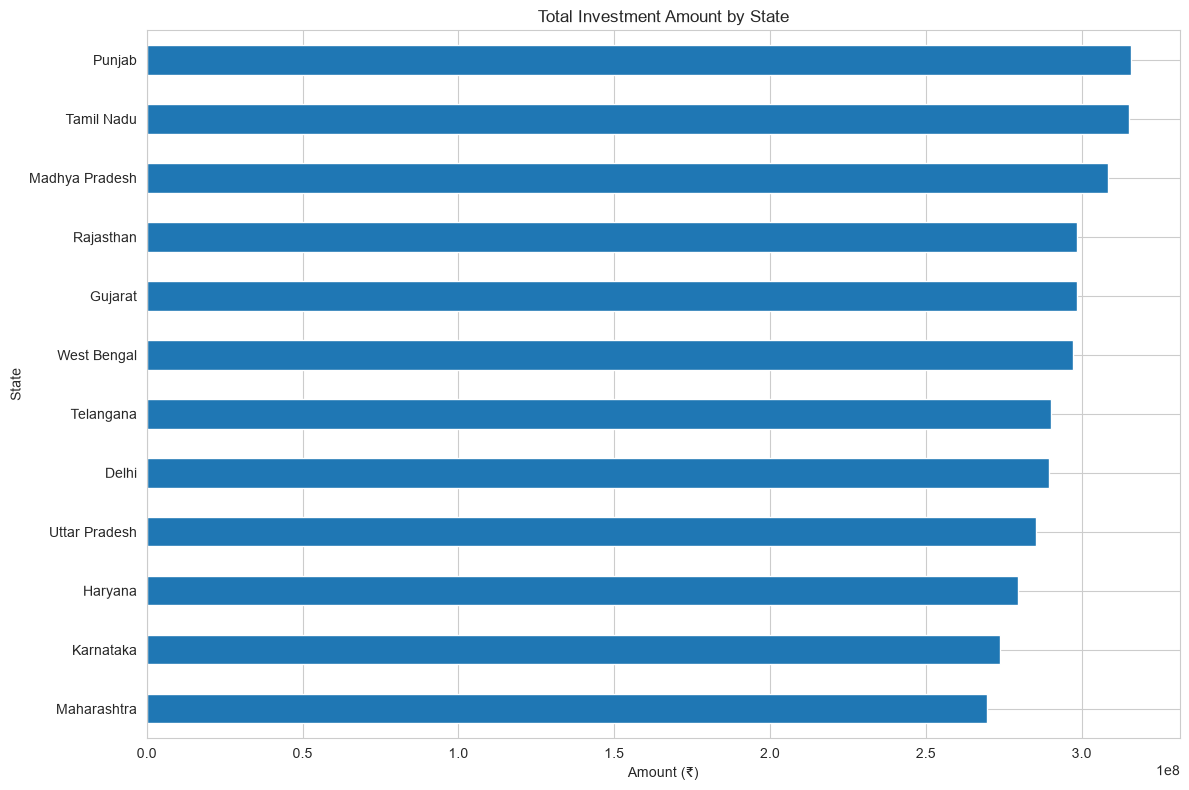

In [24]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")

plt.xlabel("Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../charts/geography/state_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

Investment activity is concentrated in a few states, while several regions contribute comparatively smaller investment volumes, indicating regional differences in mutual fund participation.

**Chart Reference:** Figure 8 – Investment Amount by State

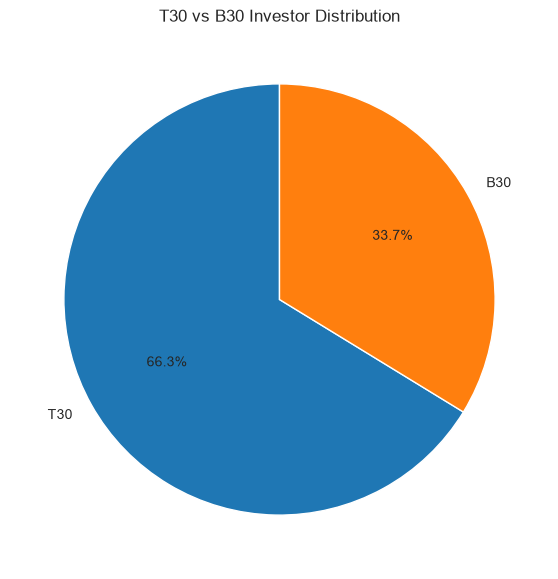

In [25]:
plt.figure(figsize=(7,7))

tier = transactions["city_tier"].value_counts()

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../charts/geography/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9

The city-tier distribution provides a comparison between investments originating from top metropolitan locations (T30) and emerging markets (B30), highlighting the geographic spread of investor participation.

**Chart Reference:** Figure 9 – T30 vs B30 Distribution

# 7. Industry Folio Growth

This visualization tracks the growth in total mutual fund folios over the analysis period, highlighting key milestones in investor participation.

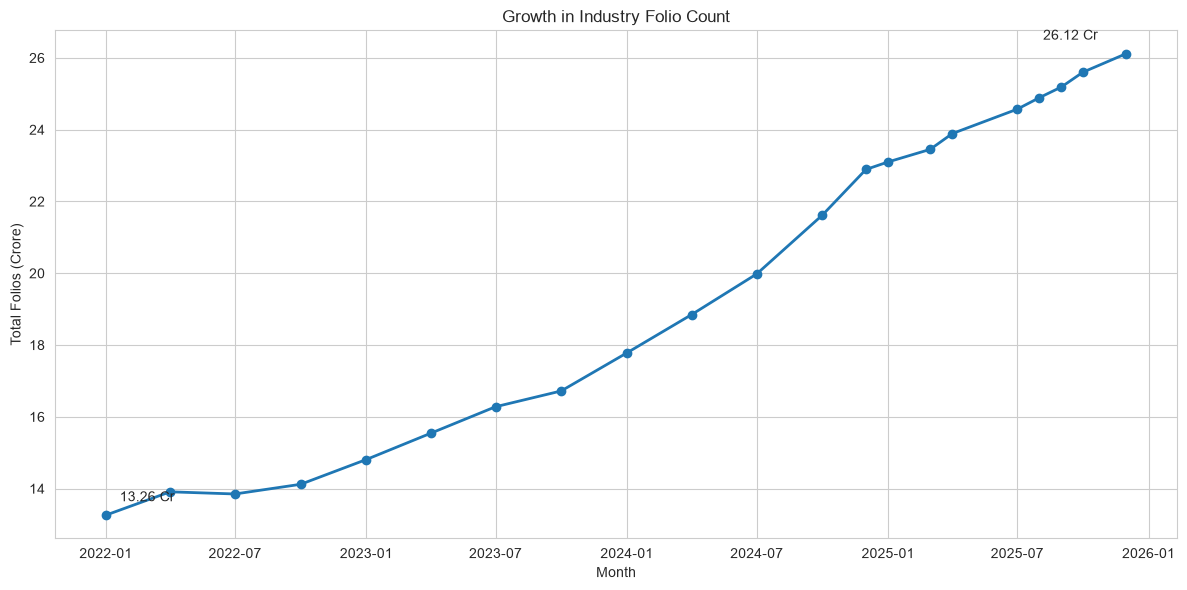

In [27]:
# ======================================================
# Folio Count Growth
# ======================================================

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Annotate first and last points
plt.annotate(
    f"{folios.iloc[0]['total_folios_crore']} Cr",
    (folios.iloc[0]["month"], folios.iloc[0]["total_folios_crore"]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.annotate(
    f"{folios.iloc[-1]['total_folios_crore']} Cr",
    (folios.iloc[-1]["month"], folios.iloc[-1]["total_folios_crore"]),
    xytext=(-60,10),
    textcoords="offset points"
)

plt.title("Growth in Industry Folio Count")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/folio/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 10

The number of mutual fund folios increased steadily throughout the analysis period, indicating sustained growth in investor participation and broader adoption of mutual fund investments.

**Chart Reference:** Figure 10 – Industry Folio Growth

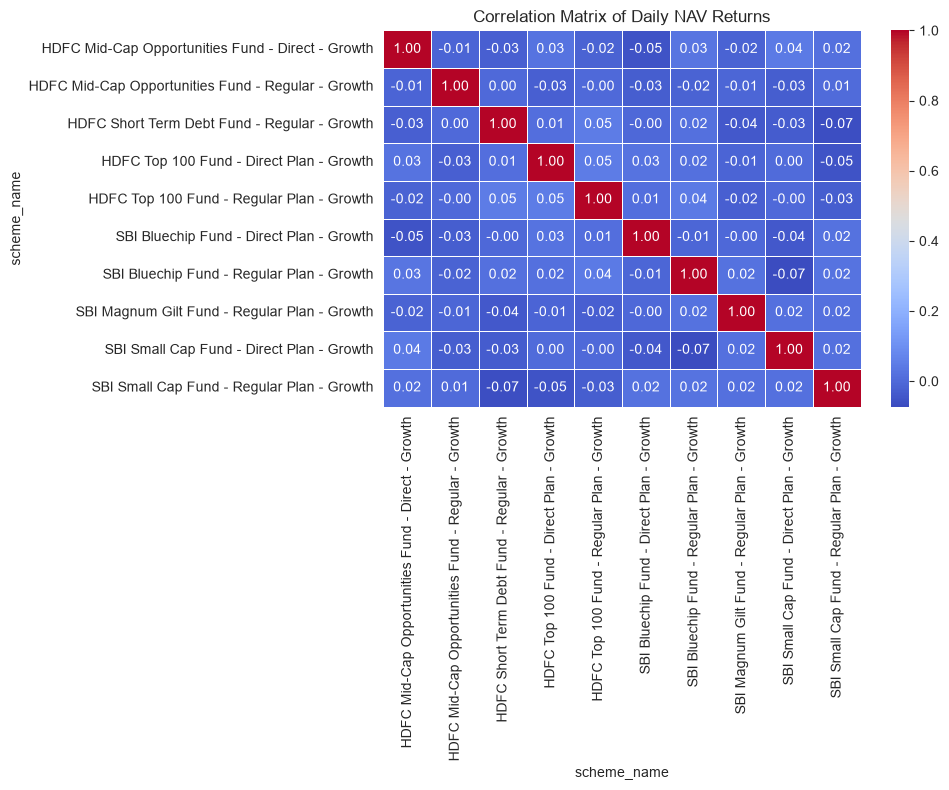

In [29]:
# ======================================================
# NAV Return Correlation
# ======================================================

# Select first 10 AMFI codes
selected = fund_master["amfi_code"].unique()[:10]

corr_df = nav_history[
    nav_history["amfi_code"].isin(selected)
].copy()

corr_df = corr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

pivot = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Daily returns
returns = pivot.pct_change()

correlation = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../charts/correlation/nav_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

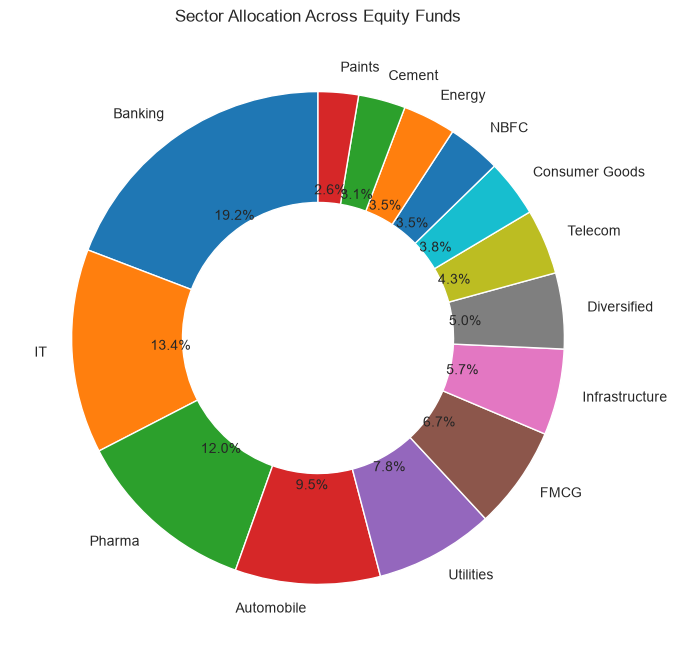

In [31]:
# ======================================================
# Sector Allocation
# ======================================================

sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../charts/sector/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Top Performing Funds (5-Year Return)

This chart ranks the top 10 mutual fund schemes based on their 5-year returns.

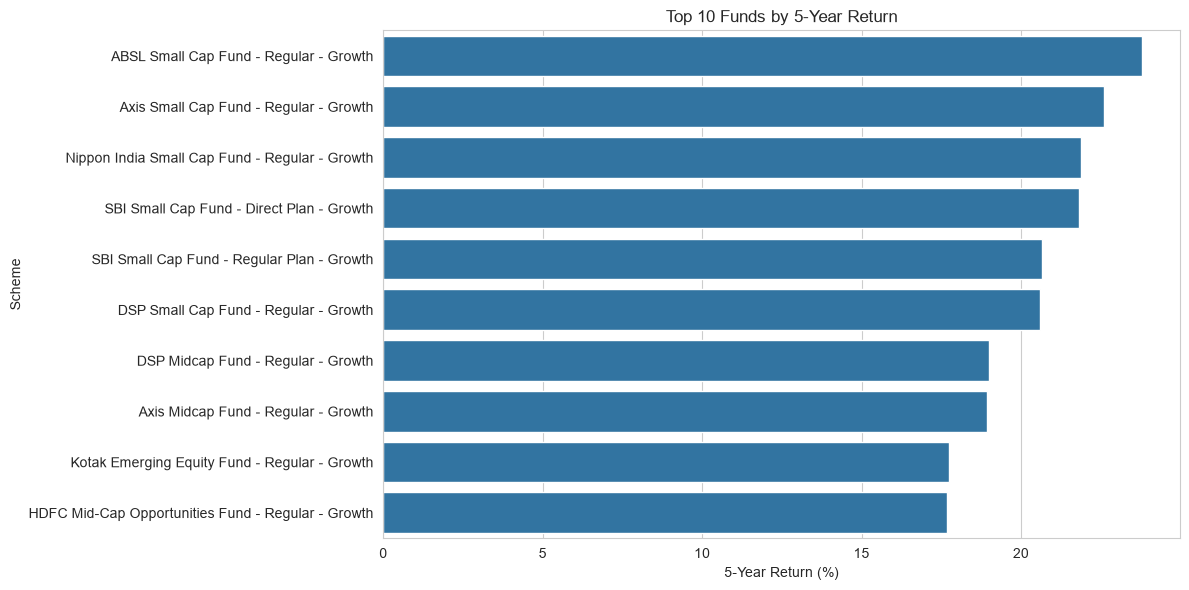

In [32]:
top10 = (
    performance
    .sort_values("return_5yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../charts/performance/top10_5yr_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 11

A small group of mutual fund schemes consistently delivered the highest five-year returns, indicating sustained long-term performance within the dataset.

**Chart Reference:** Figure 11 – Top 10 Funds by 5-Year Return

# 11. Expense Ratio Distribution

This histogram shows how expense ratios are distributed across mutual fund schemes.

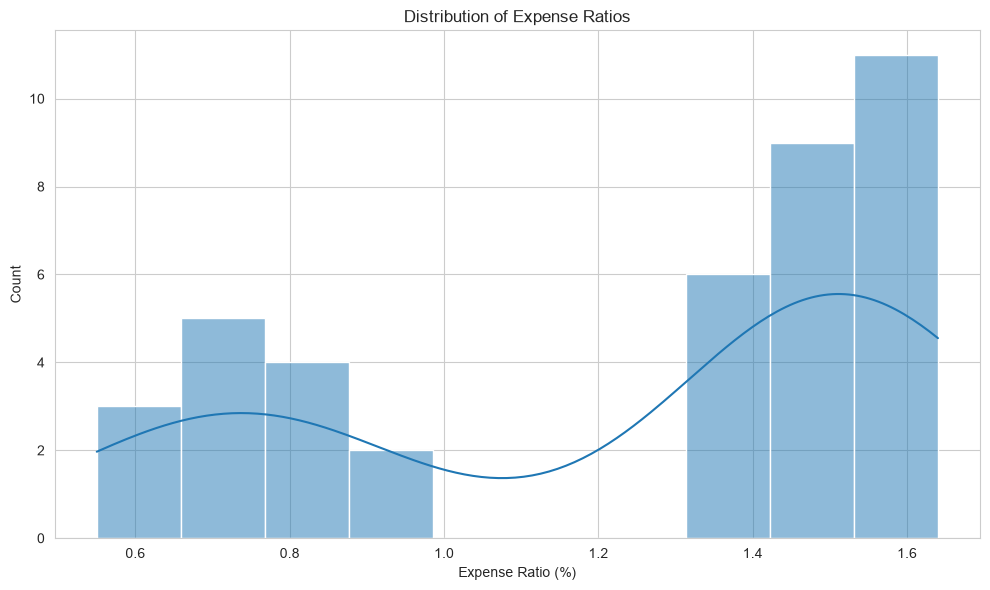

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of Expense Ratios")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.savefig(
    "../charts/performance/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 12

Most schemes have expense ratios clustered within a relatively narrow range, suggesting a consistent pricing structure across the sampled mutual funds.

**Chart Reference:** Figure 12 – Expense Ratio Distribution

# 12. Benchmark Index Trend

This chart visualizes the movement of benchmark indices over the analysis period.

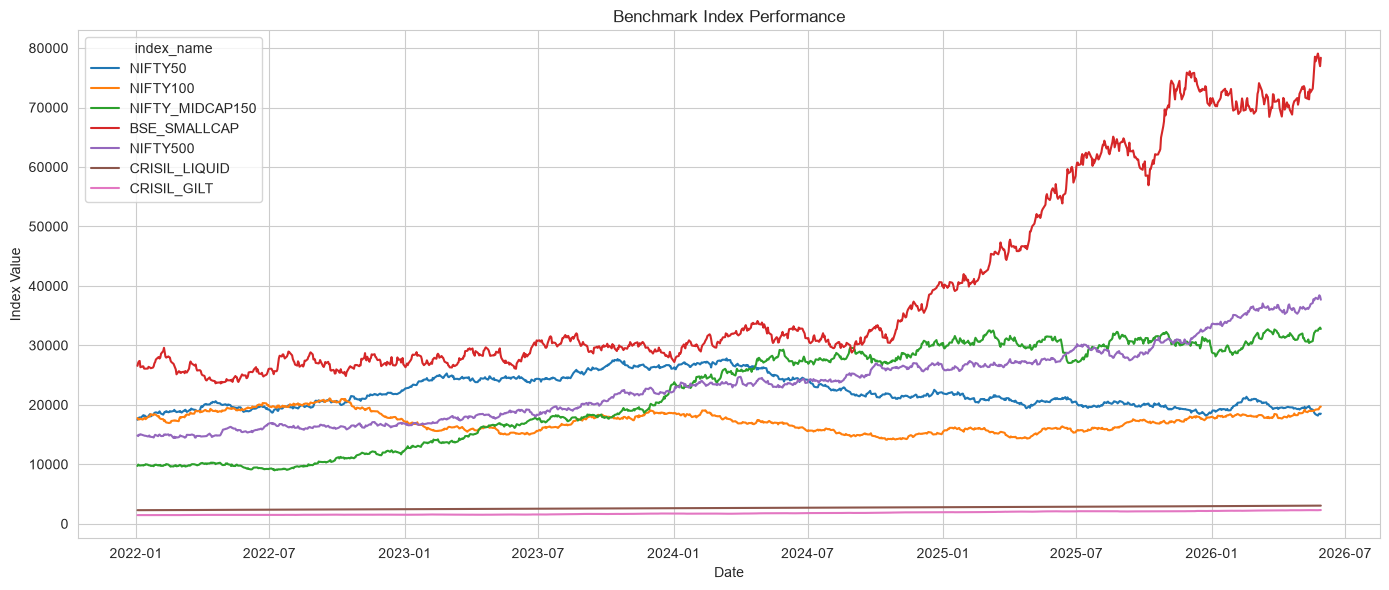

In [34]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=benchmark,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Performance")

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.tight_layout()

plt.savefig(
    "../charts/benchmark/benchmark_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 13

Benchmark indices generally followed an upward trend over the study period, reflecting broader market growth while also exhibiting periods of increased volatility.

**Chart Reference:** Figure 13 – Benchmark Index Trend

# 13. Morningstar Rating Distribution

This chart summarizes the distribution of Morningstar ratings across mutual fund schemes.

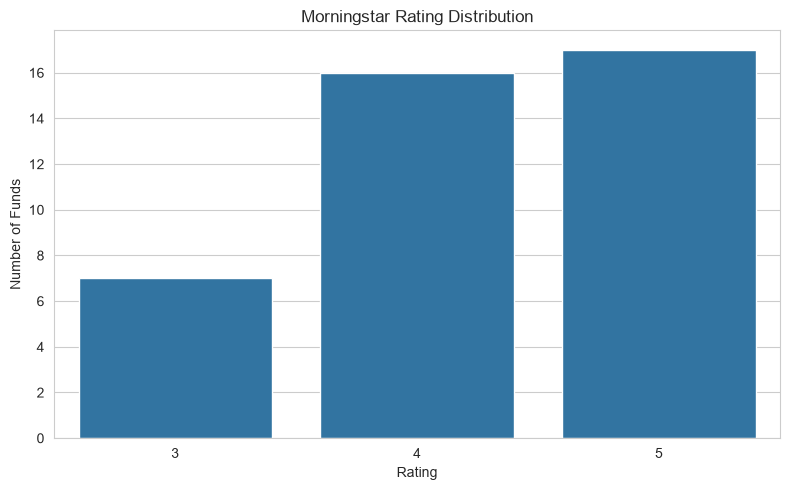

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    "../charts/performance/morningstar_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 14

Most mutual fund schemes are concentrated around the middle-to-higher Morningstar rating categories, indicating generally favorable historical performance among the sampled funds.

**Chart Reference:** Figure 14 – Morningstar Rating Distribution

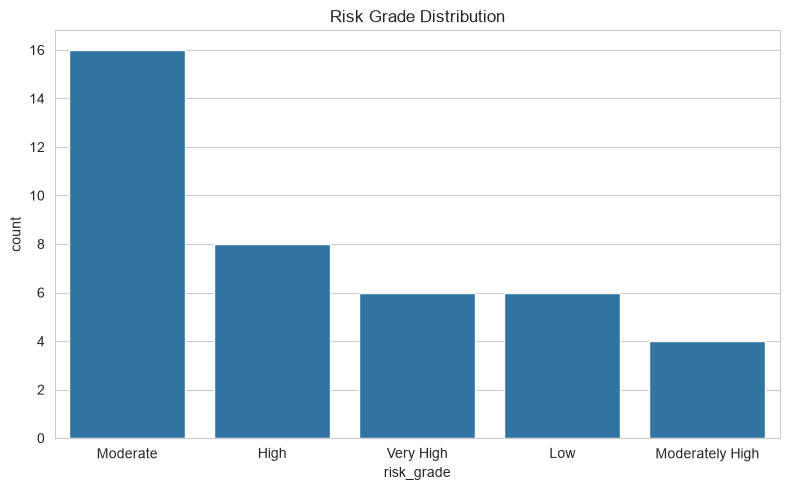

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade",
    order=performance["risk_grade"].value_counts().index
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/performance/risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 15

Risk grades are distributed across multiple categories, with a larger concentration of schemes in moderate-to-high risk segments, reflecting the composition of the dataset.

**Chart Reference:** Figure 15 – Risk Grade Distribution